# Simulated annealing

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
from IPython import display

from mpl_toolkits.mplot3d import Axes3D

# Target distribution

We use  the [peaks](https://www.mathworks.com/help/matlab/ref/peaks.html) function from matlab, modified so it is positive:
$$
p(x,y) \propto  |3 (1-x)^2 e^{-x^2 - (y+1)^2}  
   - 10 (\frac{x}{5} - x^3 - y^5) e^{-x^2 -y^2}
   - \frac{1}{3} e^{-(x+1)^2 - y^2} |
$$


In [2]:
def abs_peaks_func(x, y):
    # in contrast to the peaks function: all negative values are multiplied by (-1)
    return jnp.abs(
        3.0 * (1 - x) ** 2 * jnp.exp(-(x**2) - (y + 1) ** 2)
        - 10.0 * (x / 5 - x**3 - y**5) * jnp.exp(-(x**2) - y**2)
        - 1.0 / 3 * jnp.exp(-((x + 1) ** 2) - y**2)
    )

In [3]:
# Generate a pdf

# the following steps generate a pdf; this is equivalent to the function "peaks(n)" in matlab
n = 100  # number of dimension
pdf = np.zeros([n, n])
sigma = jnp.zeros([n, n])
# s = jnp.zeros([n, n])
x = -3.0
for i in range(0, n):
    y = -3.0
    for j in range(0, n):
        pdf[j, i] = abs_peaks_func(x, y)
        y = y + 6.0 / (n - 1)
    x = x + 6.0 / (n - 1)

pdf = jnp.array(pdf)
pdf = pdf / pdf.max()
energy = -jnp.log(pdf)

2024-08-07 09:28:09.500273: W external/xla/xla/service/gpu/nvptx_compiler.cc:765] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.5.82). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [6]:
def plot_3d_surface(x, y, pdf, title=None):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    x, y = jnp.meshgrid(x, y)
    surf = ax.plot_surface(y, x, pdf, rstride=2, cstride=2, cmap=plt.cm.coolwarm, linewidth=0.1)
    if title:
        ax.set_title(title)
    plt.tight_layout()

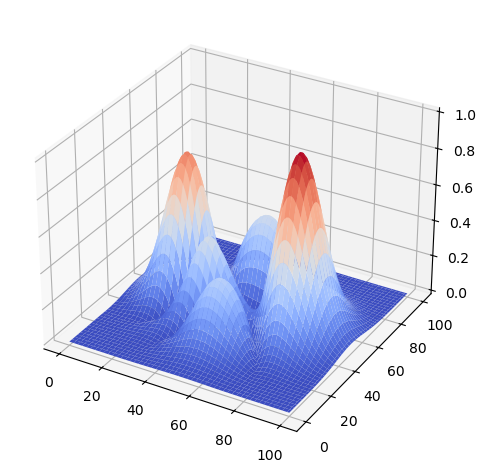

In [7]:
# Plot the 3D plot of pdf
# --------------------------
# %matplotlib inline
X = jnp.arange(0, 100 + 100.0 / (n - 1), 100.0 / (n - 1))
Y = jnp.arange(0, 100 + 100.0 / (n - 1), 100.0 / (n - 1))
plot_3d_surface(Y, X, pdf)

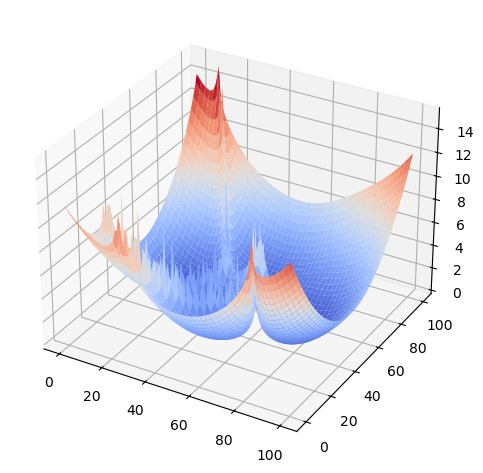

In [8]:
# Plot the 3D plot of Energy function
# --------------------------
plot_3d_surface(X, Y, energy)

# Heat bath

The "heat bath" refers to a modified version of the distribution in which we vary the temperature.

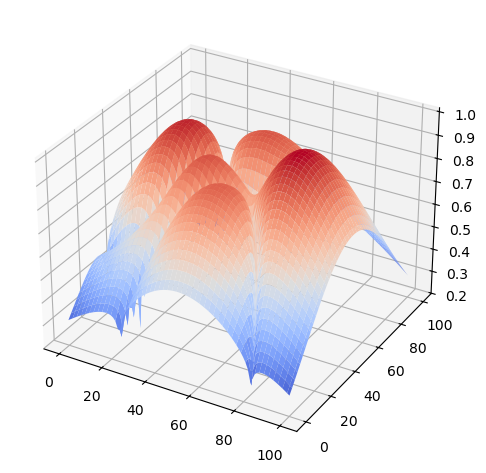

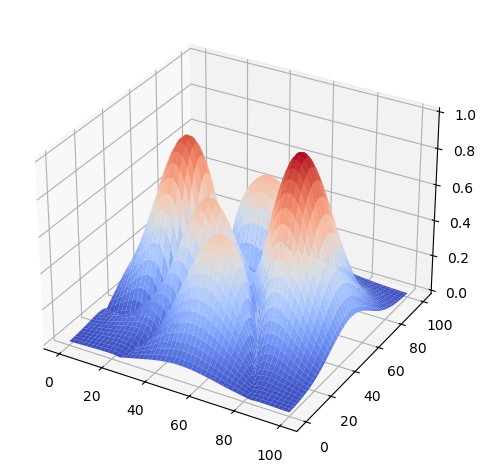

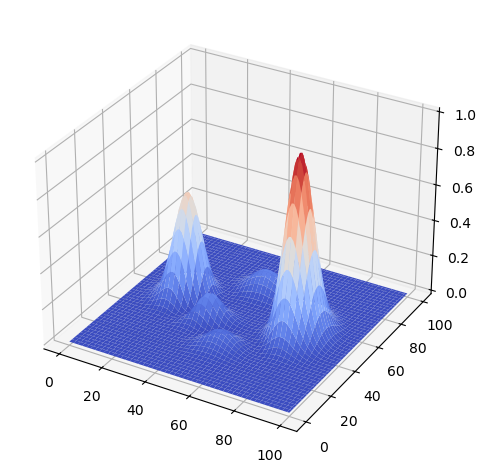

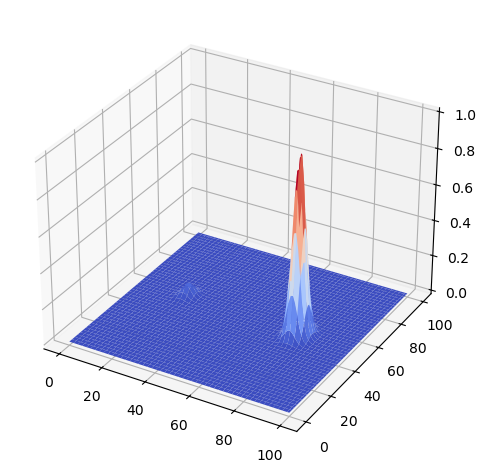

In [9]:
temperature = 10  # initial temperature for the plots
stepT = 4  # how many steps should the Temperature be *0.2  for
x = np.arange(0, 100 + 100.0 / (n - 1), 100.0 / (n - 1))
y = np.arange(0, 100 + 100.0 / (n - 1), 100.0 / (n - 1))
for i in range(0, stepT):
    sigma = np.exp(-(energy) / temperature)
    sigma = sigma / sigma.max()
    ttl = "T={:0.2f}".format(temperature)
    temperature = temperature * 0.2
    plot_3d_surface(x, y, sigma)

# SA algorithm

In [10]:
def sim_anneal(proposal="gaussian", sigma=10, seed=jax.random.PRNGKey(0)):
    # jnp.random.seed(42)
    seed1, seed2 = jax.random.split(seed)
    x_start = jnp.array(
        [
            jnp.floor(jax.random.uniform(seed1, minval=0, maxval=100)),
            jnp.floor(jax.random.uniform(seed2, minval=0, maxval=100)),
        ]
    )  # x_start
    xcur = x_start.astype(int)  # x current
    n_samples = 300  # number of samples to keep
    T = 1  # start temperature
    alpha = 0.99  # cooling schedule

    # list of visited points, temperatures, probabilities
    x_hist = xcur  # will be (N,2) array
    prob_hist = []
    temp_hist = []

    nreject = 0
    iis = 0  # number of accepted points
    n_proposed_points = 0  # num proposed points
    while n_proposed_points < n_samples:
        _, seed = jax.random.split(seed)
        n_proposed_points = n_proposed_points + 1
        if proposal == "uniform":
            seeds = jax.random.split(seed)
            xnew = jnp.array(
                [
                    jnp.floor(jax.random.uniform(seeds[0], minval=0, maxval=100)),
                    jax.random.uniform(seeds[1], minval=0, maxval=100),
                ]
            )
            # print(xnew)
        elif proposal == "gaussian":
            xnew = xcur + jax.random.normal(seed, shape=(2,)) * sigma
            xnew = jnp.maximum(xnew, 0)
            xnew = jnp.minimum(xnew, 99)
        else:
            raise ValueError("Unknown proposal")
        xnew = xnew.astype(int)

        # compare energies
        Ecur = energy[xcur[0], xcur[1]]
        Enew = energy[xnew[0], xnew[1]]
        deltaE = Enew - Ecur
        # print([n_proposed_points, xcur, xnew, Ecur, Enew, deltaE])

        temp_hist.append(T)
        T = alpha * T
        p_accept = jnp.exp(-1.0 * deltaE / T)
        # print(p_accept)
        p_accept = min(1, p_accept)
        test = jax.random.uniform(jax.random.split(seed)[0], minval=0, maxval=1)
        # print(test)
        if test <= p_accept:
            xcur = xnew
            iis = iis + 1
        else:
            nreject += 1

        x_hist = jnp.vstack((x_hist, xcur))
        prob_hist.append(pdf[xcur[0], xcur[1]])

    n_proposed_points = n_proposed_points + 1
    print(f"jnproposed {n_proposed_points}, naccepted {iis}, nreject {nreject}")
    return x_hist, prob_hist, temp_hist

# Run experiments

In [11]:
proposals = ["gaussian", "uniform"]
x_hist = {}
prob_hist = {}
temp_hist = {}
for proposal in proposals:
    print(proposal)
    x_hist[proposal], prob_hist[proposal], temp_hist[proposal] = sim_anneal(
        proposal=proposal, seed=jax.random.PRNGKey(25)
    )

gaussian
jnproposed 301, naccepted 92, nreject 208
uniform
jnproposed 301, naccepted 33, nreject 267


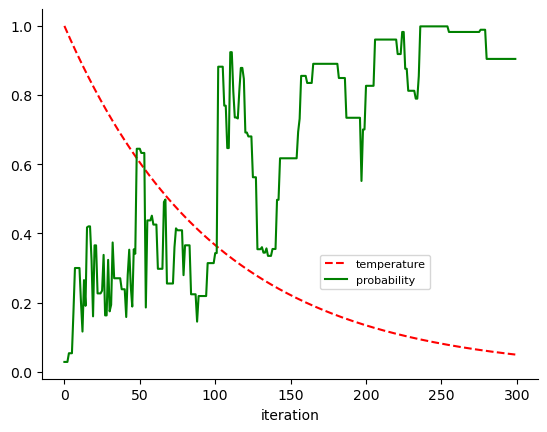

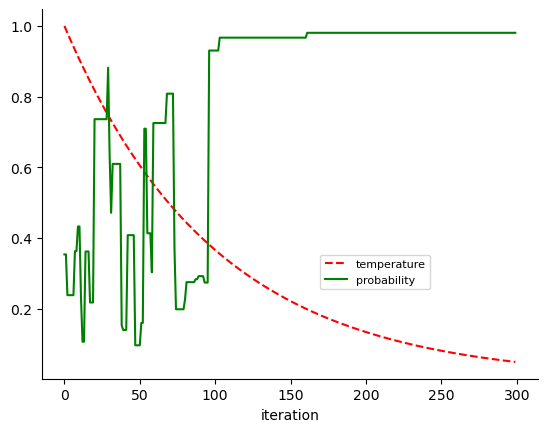

In [12]:
for proposal in proposals:
    plt.figure()
    plt.plot(
        temp_hist[proposal],
        "r--",
        label="temperature",
    )
    plt.plot(prob_hist[proposal], "g-", label="probability")
    # pml.savefig(f"sim_anneal_2d_temp_vs_time_{proposal}.pdf")

    plt.xlabel("iteration")
    sns.despine()
    plt.legend(bbox_to_anchor=(0.55, 0.35), fontsize=8)

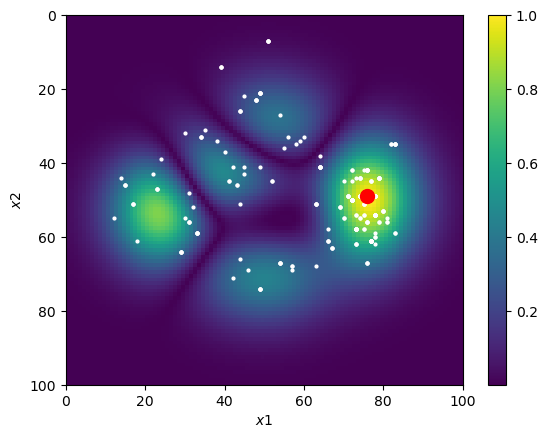

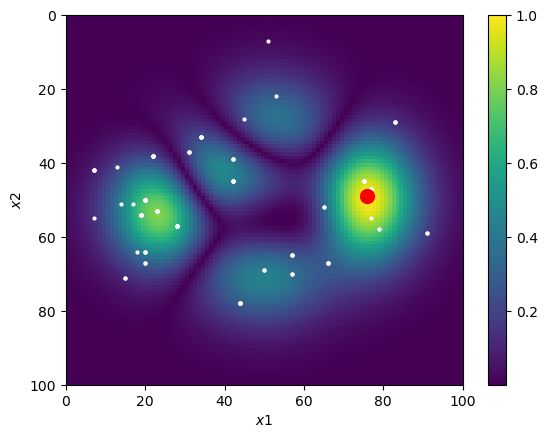

In [13]:
# Plot points visited
global_markersize = 10
step_markersize = 4
for proposal in proposals:
    probs = prob_hist[proposal]
    xa = x_hist[proposal]

    fig = plt.figure()
    ax = plt.gca()
    contour = ax.imshow(pdf.transpose(), aspect="auto", extent=[0, 100, 100, 0], interpolation="none")
    # contour = plt.contourf(pdf.transpose(), aspect="auto", extent=[0, 100, 100, 0])
    fig.colorbar(contour, ax=ax)

    # Starting point with white cirlce
    # ax.plot(xa[0, 0], xa[0, 1], "ro", markersize=10)

    # Global maximm with red cirlce
    ind = np.unravel_index(np.argmax(pdf, axis=None), pdf.shape)

    ax.plot(xa[:, 0], xa[:, 1], "w.", markersize=step_markersize)  # Plot the steps with white +4
    ax.plot(ind[0], ind[1], "ro", markersize=global_markersize, label="global maxima")  # max point

    ax.set_ylabel("$x2$")
    ax.set_xlabel("$x1$")
    #     plt.legend(framealpha=0.5)